## Setup and Data Loading

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import json

# Set academic plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 12, 'figure.dpi': 150})

# 1. Load the JSON data
with open('final_evaluation_data.json', 'r') as f:
    data = json.load(f)

# 2. Convert to Pandas DataFrames for easy plotting
df_robots = pd.DataFrame(data['sweep_robots'])
df_holes = pd.DataFrame(data['sweep_holes'])

print("Data successfully loaded!")
display(df_robots.head(2))
display(df_holes.head(2))

Data successfully loaded!


,robots,holes,avg_time,success_rate
0,6,2,53.9648,100.0
1,7,2,54.7456,100.0


,robots,holes,avg_time,success_rate
0,10,1,66.5536,96.0
1,10,2,50.0288,100.0


## The Congestion Curve (Tipping Point)

C:\Users\tasio\AppData\Local\Temp\ipykernel_43056\3801216491.py:33: UserWarning: Legend does not support handles for list instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  ax2.legend(lines + [lines2], labels + labels2, loc='upper left')


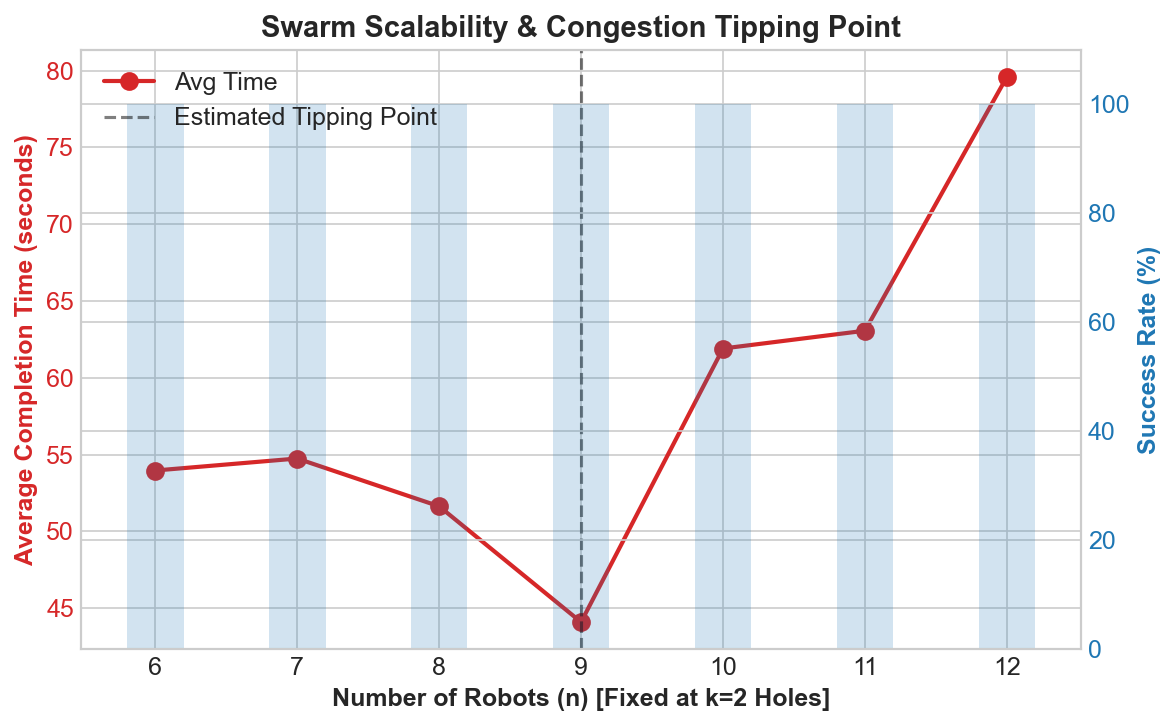

In [3]:
fig, ax1 = plt.subplots(figsize=(8, 5))

# Primary Axis (Left) - Average Time
color = 'tab:red'
ax1.set_xlabel('Number of Robots (n) [Fixed at k=2 Holes]', fontweight='bold')
ax1.set_ylabel('Average Completion Time (seconds)', color=color, fontweight='bold')
line1 = ax1.plot(df_robots['robots'], df_robots['avg_time'], marker='o', 
                 color=color, linewidth=2, markersize=8, label='Avg Time')
ax1.tick_params(axis='y', labelcolor=color)

# Define the "Tipping Point" visually (e.g., where the slope suddenly gets steep)
# We highlight this with a vertical dashed line. You may need to adjust the x-value (e.g., 9 or 10) 
# based on what your actual data shows!
tipping_point_x = 9  
ax1.axvline(x=tipping_point_x, color='black', linestyle='--', alpha=0.5, label='Estimated Tipping Point')

# Secondary Axis (Right) - Success Rate
ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('Success Rate (%)', color=color, fontweight='bold')
line2 = ax2.bar(df_robots['robots'], df_robots['success_rate'], alpha=0.2, 
                color=color, width=0.4, label='Success Rate')
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(0, 110) # Keep bars visually grounded

# Add titles and legends
plt.title('Swarm Scalability & Congestion Tipping Point', fontweight='bold', fontsize=14)
fig.tight_layout()

# Merge legends from both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + [lines2], labels + labels2, loc='upper left')

plt.show()

# Save for the report
fig.savefig('graph1_congestion.png', bbox_inches='tight', dpi=300)

## The Relief Curve (Diminishing Returns)

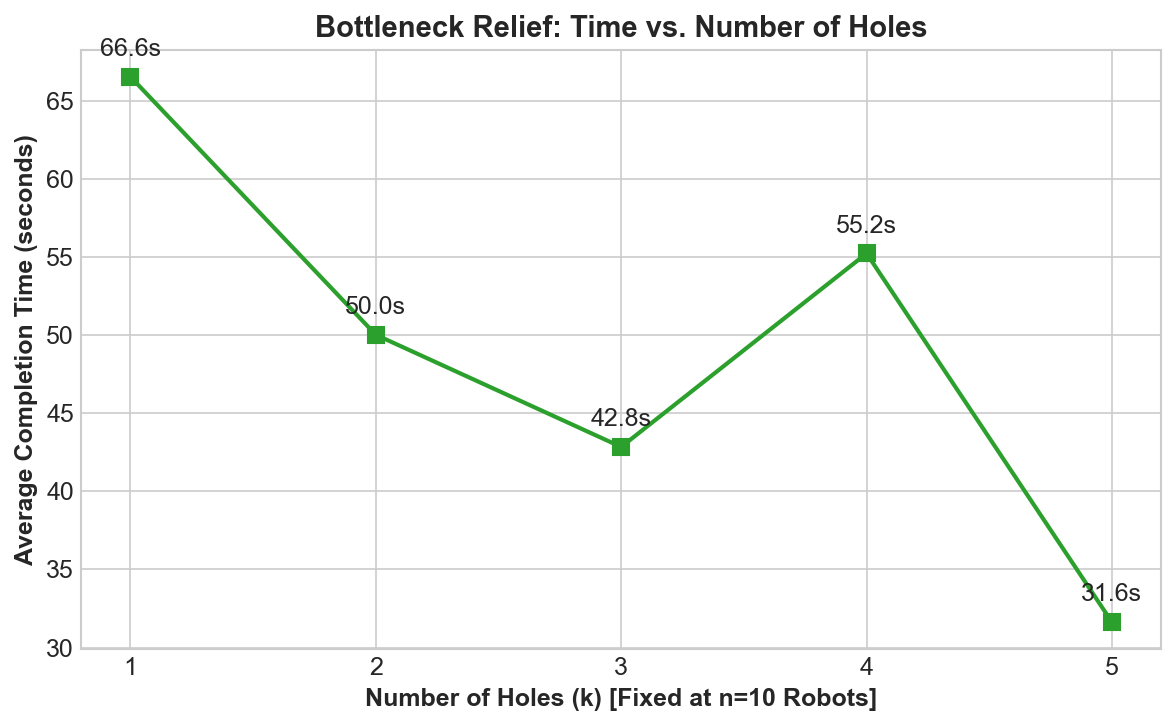

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))

# Plot the time vs holes
ax.plot(df_holes['holes'], df_holes['avg_time'], marker='s', color='tab:green', 
        linewidth=2, markersize=8, linestyle='-')

# Formatting
ax.set_title('Bottleneck Relief: Time vs. Number of Holes', fontweight='bold', fontsize=14)
ax.set_xlabel('Number of Holes (k) [Fixed at n=10 Robots]', fontweight='bold')
ax.set_ylabel('Average Completion Time (seconds)', fontweight='bold')
ax.set_xticks(df_holes['holes']) # Force x-axis to show integer hole counts only

# Add data labels directly on the points to highlight the "leveling off" effect
for i, txt in enumerate(df_holes['avg_time']):
    ax.annotate(f"{txt:.1f}s", 
                (df_holes['holes'].iloc[i], df_holes['avg_time'].iloc[i]),
                textcoords="offset points", xytext=(0,10), ha='center')

fig.tight_layout()
plt.show()

# Save for the report
fig.savefig('graph2_bottleneck.png', bbox_inches='tight', dpi=300)

For Graph 1 (Congestion): Look at the red line. It should start relatively flat (linear). At some point (likely between 8 and 10 robots), the line will suddenly point almost straight up. Note this exact number in your text. Insight: "The swarm exhibits fluid-like flow up to $n=8$. Beyond this tipping point, the physical footprint of the robots exceeds the spatial capacity of the bottlenecks, triggering severe w_separation interference and jamming.

"For Graph 2 (Relief): Look at the green line. It should look like an 'L' shape (an exponential decay curve). Note the difference in time between 1 hole and 2 holes, versus 3 holes and 4 holes. Insight: "Adding a second hole reduced completion time by X%. However, beyond $k=3$, the wall ceases to be the primary limiting factor, and completion time approaches the physical speed limit of the e-puck motors."